# Machine Learning - Clustering (Diabetes)

[![francomansilla.com](https://img.shields.io/badge/francomansilla.com-555555?style=flat&logo=globe&logoColor=white)](https://www.francomansilla.com)

Este notebook combina aprendizaje supervisado y no supervisado sobre el dataset de diabetes. Primero se entrena y compara un modelo de clasificacion (MLP) para predecir `Outcome`, y luego se desarrolla un flujo de clustering con K-Means para segmentar perfiles de pacientes y analizar diferencias entre grupos.

<br>

**Librerias**

[![Pandas](https://img.shields.io/badge/Pandas-150458?style=flat&logo=pandas&logoColor=white)](https://pandas.pydata.org/docs/)
[![NumPy](https://img.shields.io/badge/NumPy-013243?style=flat&logo=numpy&logoColor=white)](https://numpy.org/doc/)
[![Matplotlib](https://img.shields.io/badge/Matplotlib-11557c?style=flat&logo=python&logoColor=white)](https://matplotlib.org/stable/index.html)
[![scikit-learn](https://img.shields.io/badge/scikit--learn-F7931E?style=flat&logo=scikit-learn&logoColor=white)](https://scikit-learn.org/stable/)
[![Plotly](https://img.shields.io/badge/Plotly-3F4F75?style=flat&logo=plotly&logoColor=white)](https://plotly.com/python/)

**Modelos y metodos**

[![MLPClassifier](https://img.shields.io/badge/MLPClassifier-0078D4?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
[![KMeans](https://img.shields.io/badge/KMeans-006400?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
[![PCA](https://img.shields.io/badge/PCA-8B0000?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
[![Pipeline](https://img.shields.io/badge/Pipeline-6A0DAD?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
[![GridSearchCV](https://img.shields.io/badge/GridSearchCV-E34F26?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
[![StandardScaler](https://img.shields.io/badge/StandardScaler-2E8B57?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

**Metricas**

[![Accuracy](https://img.shields.io/badge/Accuracy-DC143C?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
[![F1](https://img.shields.io/badge/F1_Score-B8860B?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)
[![ROC-AUC](https://img.shields.io/badge/ROC--AUC-228B22?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html)
[![Silhouette](https://img.shields.io/badge/Silhouette-1E90FF?style=flat&logo=python&logoColor=white)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)

---


## Librerías y Paquetes

En esta sección se importan todas las librerías usadas en el notebook.

- `pandas` y `numpy` para manipulación de datos.
- `matplotlib` y `plotly` para visualización estática e interactiva.
- `scikit-learn` para preprocesamiento, modelado supervisado y clustering.

Dejar todos los imports en una sola celda mejora la organización y facilita la ejecución secuencial del análisis.

In [31]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score
    )
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### Clustering no supervisado (K-Means)

Ahora aplicamos clustering para segmentar perfiles de pacientes sin usar la etiqueta `Outcome` durante el entrenamiento. Se selecciona el número de clusters con *silhouette score* y luego se interpreta cada grupo comparándolo con `Outcome`.

In [32]:
# Si no esta cargado el dataset en memoria, lo volvemos a cargar
if 'df' not in globals():
    df = pd.read_csv('https://raw.githubusercontent.com/fmansillaib/umayor_class/main/datasets/datos_transversales_paneles/diabetes/datos.csv')

#### Análisis exploratorio previo para clustering

Antes de clusterizar conviene evaluar:

1. Calidad de datos: nulos, duplicados y ceros clínicamente sospechosos.
2. Escala y dispersión: variabilidad y posibles valores extremos.
3. Estructura: correlaciones y cuánta información concentran los primeros componentes principales (PCA).

Con este diagnóstico definimos una versión depurada de la base para clustering.

In [4]:
# A) Calidad de datos y depuración inicial para clustering
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

nulos = df.isna().sum()
duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

print("\nNulos por variable:")
display(nulos.to_frame('nulos'))

# En este dataset, cero suele ser valor no plausible en estas variables clínicas
cols_cero_sospechoso = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
porc_ceros = (df[cols_cero_sospechoso] == 0).mean().mul(100).round(2)
print("\n% de ceros en variables clínicas (potenciales faltantes):")
display(porc_ceros.to_frame('%_ceros'))

# Propuesta para clustering: reemplazar ceros sospechosos por mediana
# (evita que K-Means forme grupos por artefactos de codificación)
df_model = df.copy()
for col in cols_cero_sospechoso:
    mediana_col = df_model.loc[df_model[col] != 0, col].median()
    df_model.loc[df_model[col] == 0, col] = mediana_col

print("\nBase depurada creada: df_model")
print("Ceros remanentes en variables clínicas:")
display((df_model[cols_cero_sospechoso] == 0).sum().to_frame('ceros_restantes'))

Filas: 768 | Columnas: 9
Registros duplicados: 0

Nulos por variable:


,nulos
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



% de ceros en variables clínicas (potenciales faltantes):


,%_ceros
Glucose,0.0
BloodPressure,0.0
SkinThickness,0.0
Insulin,0.0
BMI,0.0



Base depurada creada: df_model
Ceros remanentes en variables clínicas:


,ceros_restantes
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


#### Análisis pre-eliminación para clustering

Este bloque sirve para decidir si conviene eliminar variables redundantes o registros atípicos antes de entrenar K-Means. La idea es evitar clusters artificiales producidos por colinealidad extrema o outliers.

In [ ]:
if 'df_model' not in globals():
    df_model = df.copy()

target = 'Outcome'
features = [c for c in df_model.columns if c != target]
X = df_model[features].copy()

print(f"Base de análisis preparada con {len(X)} filas y {len(features)} features.")

Base de análisis preparada con 768 filas y 8 features.


#### 1) Variables de baja varianza

Este análisis muestra las variables con menor variabilidad. Si una variable casi no cambia entre pacientes, puede aportar poco a la formación de clusters.

In [6]:
varianzas = X.var().sort_values()
umbral_baja_var = varianzas.quantile(0.10)
vars_baja_var = varianzas[varianzas <= umbral_baja_var]

print('Top 5 variables con menor varianza:')
display(varianzas.to_frame('varianza').head(5))

print('Variables bajo el percentil 10 de varianza:')
display(vars_baja_var.to_frame('varianza'))

Top 5 variables con menor varianza:


,varianza
DiabetesPedigreeFunction,0.088661
Pregnancies,21.642594
BMI,35.078774
SkinThickness,101.198694
BloodPressure,227.003076


Variables bajo el percentil 10 de varianza:


,varianza
DiabetesPedigreeFunction,0.088661


#### 2) Colinealidad entre variables

Aquí buscamos pares de variables muy correlacionadas. Si dos variables dicen casi lo mismo, podrías dejar solo una para simplificar el clustering.

In [7]:
corr_abs = X.corr().abs()
mask_sup = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
corr_pairs = corr_abs.where(mask_sup).stack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Corr_abs']
pares_altamente_correl = corr_pairs[corr_pairs['Corr_abs'] >= 0.75].sort_values('Corr_abs', ascending=False)

print('Pares con correlación alta (|r| >= 0.75):')
if len(pares_altamente_correl) == 0:
    print('No se detectaron pares altamente correlacionados con el umbral actual.')
else:
    display(pares_altamente_correl)

Pares con correlación alta (|r| >= 0.75):
No se detectaron pares altamente correlacionados con el umbral actual.


#### 3) Outliers por criterio IQR

Este bloque estima cuántos valores extremos hay por variable. Muchos outliers pueden distorsionar K-Means.

In [8]:
outlier_pct = {}
outlier_mask_global = np.zeros(len(X), dtype=bool)

for col in features:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    mask = (X[col] < li) | (X[col] > ls)
    outlier_pct[col] = mask.mean() * 100
    outlier_mask_global = outlier_mask_global | mask

outlier_pct = pd.Series(outlier_pct).sort_values(ascending=False)
porc_filas_outlier = outlier_mask_global.mean() * 100

print('% de outliers por variable (IQR):')
display(outlier_pct.round(2).to_frame('%_outliers'))
print(f"Filas marcadas como outlier en al menos una variable: {porc_filas_outlier:.2f}%")

% de outliers por variable (IQR):


,%_outliers
BMI,1.82
BloodPressure,1.43
Insulin,1.04
Glucose,0.39
DiabetesPedigreeFunction,0.39
SkinThickness,0.13
Pregnancies,0.00
Age,0.00


Filas marcadas como outlier en al menos una variable: 5.08%


#### 4) Proporción de valores únicos

Este indicador muestra qué tan diversa es cada variable. Valores muy bajos pueden indicar poca capacidad de separar perfiles.

In [9]:
proporcion_unicos = pd.DataFrame({
    'total': len(X),
    'valores_unicos': X.nunique(dropna=False)
})
proporcion_unicos['proporcion_unicos'] = (
    proporcion_unicos['valores_unicos'] / proporcion_unicos['total']
).round(4)
proporcion_unicos['proporcion_unicos_%'] = (proporcion_unicos['proporcion_unicos'] * 100).round(2)

print('Proporción de valores únicos por variable:')
display(proporcion_unicos.sort_values('proporcion_unicos', ascending=False))

filas_unicas = X.drop_duplicates().shape[0]
prop_filas_unicas = filas_unicas / len(X)
print(f"Filas únicas (features) / total: {filas_unicas}/{len(X)} = {prop_filas_unicas:.4f} ({prop_filas_unicas*100:.2f}%)")

Proporción de valores únicos por variable:


,total,valores_unicos,proporcion_unicos,proporcion_unicos_%
Insulin,768,690,0.8984,89.84
DiabetesPedigreeFunction,768,552,0.7188,71.88
Glucose,768,548,0.7135,71.35
BloodPressure,768,420,0.5469,54.69
SkinThickness,768,332,0.4323,43.23
BMI,768,246,0.3203,32.03
Age,768,61,0.0794,7.94
Pregnancies,768,16,0.0208,2.08


Filas únicas (features) / total: 768/768 = 1.0000 (100.00%)


#### 5) PCA antes de la tramificación

Aplicamos PCA para resumir la información de las variables en pocos componentes y visualizar mejor la estructura de los datos antes de crear deciles.

Componentes para 80% de varianza acumulada: 7
Componentes para 90% de varianza acumulada: 8
Componentes para 95% de varianza acumulada: 8

Varianza explicada PC1: 14.84%
Varianza explicada PC2: 13.71%
Varianza acumulada (2 PCs): 28.55%


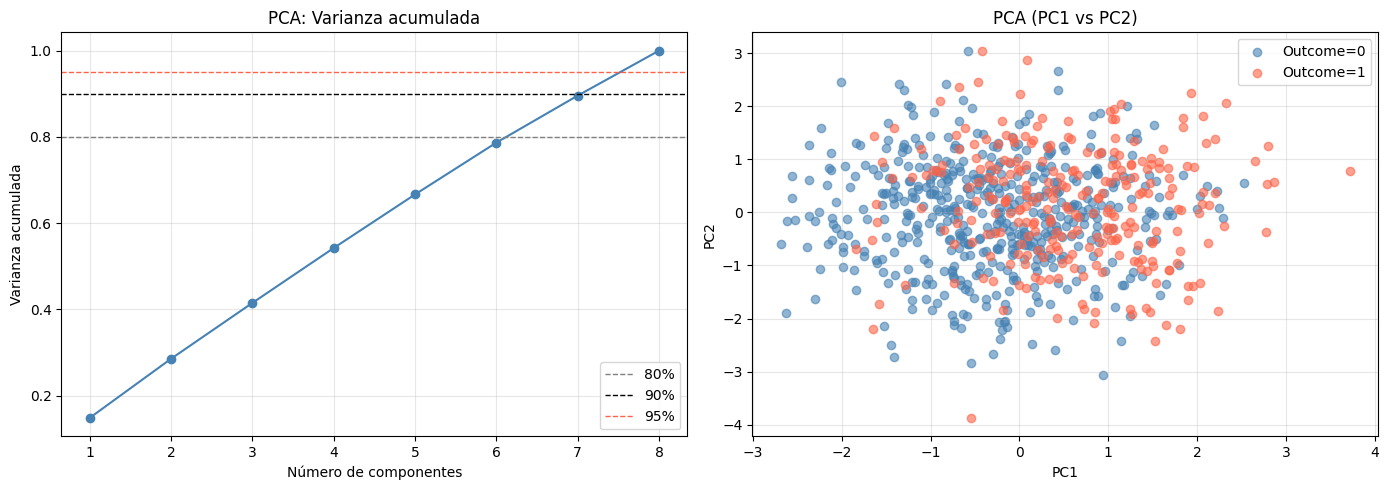

In [10]:
# PCA simple previo a la tramificación
X_sc = StandardScaler().fit_transform(X)

# PCA completo para decidir cuántos componentes usar
pca_full = PCA().fit(X_sc)
var_exp_full = pca_full.explained_variance_ratio_
var_acum_full = np.cumsum(var_exp_full)

n_comp_80 = int(np.argmax(var_acum_full >= 0.80) + 1)
n_comp_90 = int(np.argmax(var_acum_full >= 0.90) + 1)
n_comp_95 = int(np.argmax(var_acum_full >= 0.95) + 1)

print(f"Componentes para 80% de varianza acumulada: {n_comp_80}")
print(f"Componentes para 90% de varianza acumulada: {n_comp_90}")
print(f"Componentes para 95% de varianza acumulada: {n_comp_95}")

# Base PCA para modelar (usamos 90% de varianza acumulada)
pca_model = PCA(n_components=n_comp_90, random_state=42)
X_pca_model = pca_model.fit_transform(X_sc)
df_pca_model = pd.DataFrame(
    X_pca_model,
    columns=[f"PC{i+1}" for i in range(X_pca_model.shape[1])]
)
if target in df_model.columns:
    df_pca_model[target] = df_model[target].values

# PCA en 2 componentes para visualización
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)
var_exp = pca.explained_variance_ratio_

print(f"\nVarianza explicada PC1: {var_exp[0]*100:.2f}%")
print(f"Varianza explicada PC2: {var_exp[1]*100:.2f}%")
print(f"Varianza acumulada (2 PCs): {(var_exp[0]+var_exp[1])*100:.2f}%")

df_pca_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
if 'target' in globals() and target in df_model.columns:
    df_pca_plot[target] = df_model[target].values

# Ambos gráficos juntos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: varianza acumulada
axes[0].plot(range(1, len(var_acum_full) + 1), var_acum_full, marker='o', color='steelblue')
axes[0].axhline(0.80, linestyle='--', color='gray', linewidth=1, label='80%')
axes[0].axhline(0.90, linestyle='--', color='black', linewidth=1, label='90%')
axes[0].axhline(0.95, linestyle='--', color='tomato', linewidth=1, label='95%')
axes[0].set_title('PCA: Varianza acumulada')
axes[0].set_xlabel('Número de componentes')
axes[0].set_ylabel('Varianza acumulada')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Derecha: dispersión PC1 vs PC2
if target in df_pca_plot.columns:
    for clase, color in zip(sorted(df_pca_plot[target].unique()), ['steelblue', 'tomato']):
        d = df_pca_plot[df_pca_plot[target] == clase]
        axes[1].scatter(d['PC1'], d['PC2'], alpha=0.6, label=f'{target}={clase}', color=color)
    axes[1].legend()
else:
    axes[1].scatter(df_pca_plot['PC1'], df_pca_plot['PC2'], alpha=0.6, color='steelblue')

axes[1].set_title('PCA (PC1 vs PC2)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 6) Tramificación de variables con menos de 30% de valores únicos

Después del PCA, este bloque crea deciles para variables con baja diversidad relativa.

In [11]:
# Tramificación por deciles en variables con < 30% de valores únicos
umbral_unicos = 0.30

if 'proporcion_unicos' not in globals():
    proporcion_unicos = pd.DataFrame({
        'total': len(X),
        'valores_unicos': X.nunique(dropna=False)
    })
    proporcion_unicos['proporcion_unicos'] = proporcion_unicos['valores_unicos'] / proporcion_unicos['total']

variables_tramificar = proporcion_unicos.query('proporcion_unicos < @umbral_unicos').index.tolist()
X_tramificado = X.copy()
resumen = []

for col in variables_tramificar:
    if not pd.api.types.is_numeric_dtype(X[col]) or X[col].nunique(dropna=True) < 2:
        continue

    deciles = pd.qcut(X[col], q=10, duplicates='drop')
    if deciles.nunique(dropna=True) < 2:
        continue

    nueva_col = f"{col}_decil"
    X_tramificado[nueva_col] = deciles.astype(str)

    resumen.append({
        'variable': col,
        'proporcion_unicos': round(float(proporcion_unicos.loc[col, 'proporcion_unicos']), 4),
        'n_tramos_generados': int(deciles.nunique(dropna=True)),
        'nueva_columna': nueva_col
    })

resumen_tramos = pd.DataFrame(resumen)

print(f"Umbral usado: {umbral_unicos:.0%}")
print(f"Variables candidatas: {len(variables_tramificar)}")
print(f"Variables tramificadas: {len(resumen_tramos)}")

if not resumen_tramos.empty:
    display(resumen_tramos.sort_values('proporcion_unicos'))
else:
    print('No se tramificó ninguna variable con las condiciones actuales.')

# DataFrame final con columnas de deciles
df_tramificado = df_model.copy()
columnas_deciles = [c for c in X_tramificado.columns if c.endswith('_decil')]
df_tramificado[columnas_deciles] = X_tramificado[columnas_deciles]

print('\nColumnas de deciles creadas:')
print(columnas_deciles)

Umbral usado: 30%
Variables candidatas: 2
Variables tramificadas: 2


,variable,proporcion_unicos,n_tramos_generados,nueva_columna
0,Pregnancies,0.0208,10,Pregnancies_decil
1,Age,0.0794,10,Age_decil



Columnas de deciles creadas:
['Pregnancies_decil', 'Age_decil']


#### 7) One-Hot Encoding de variables tramificadas

En esta sección transformamos las variables categóricas creadas por deciles en columnas binarias (one-hot). Esto permite comparar el desempeño de K-Means usando una representación alternativa de los datos.

In [12]:
# One-hot encoding solo para variables tramificadas (_decil)
if 'df_tramificado' not in globals():
    df_tramificado = df_model.copy()

columnas_deciles = [c for c in df_tramificado.columns if c.endswith('_decil')]

if len(columnas_deciles) == 0:
    print('No hay columnas tramificadas para codificar.')
else:
    df_ohe = pd.get_dummies(df_tramificado, columns=columnas_deciles, drop_first=False)
    nuevas_ohe = [c for c in df_ohe.columns if any(c.startswith(f"{col}_") for col in columnas_deciles)]

    print(f"Columnas tramificadas codificadas: {len(columnas_deciles)}")
    print(f"Nuevas columnas one-hot: {len(nuevas_ohe)}")
    print('\nEjemplo de columnas one-hot creadas:')
    print(nuevas_ohe[:15])

    display(df_ohe.head())

Columnas tramificadas codificadas: 2
Nuevas columnas one-hot: 20

Ejemplo de columnas one-hot creadas:
['Pregnancies_decil_(-0.001, 1.0]', 'Pregnancies_decil_(1.0, 3.0]', 'Pregnancies_decil_(11.0, 12.0]', 'Pregnancies_decil_(12.0, 14.0]', 'Pregnancies_decil_(14.0, 15.0]', 'Pregnancies_decil_(3.0, 4.0]', 'Pregnancies_decil_(4.0, 6.0]', 'Pregnancies_decil_(6.0, 8.0]', 'Pregnancies_decil_(8.0, 9.0]', 'Pregnancies_decil_(9.0, 11.0]', 'Age_decil_(20.999, 26.7]', 'Age_decil_(26.7, 32.4]', 'Age_decil_(32.4, 39.0]', 'Age_decil_(39.0, 45.0]', 'Age_decil_(45.0, 51.0]']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,"Pregnancies_decil_(-0.001, 1.0]",...,"Age_decil_(20.999, 26.7]","Age_decil_(26.7, 32.4]","Age_decil_(32.4, 39.0]","Age_decil_(39.0, 45.0]","Age_decil_(45.0, 51.0]","Age_decil_(51.0, 58.0]","Age_decil_(58.0, 64.0]","Age_decil_(64.0, 70.0]","Age_decil_(70.0, 76.0]","Age_decil_(76.0, 81.0]"
0,11,95.4,65.7,16.0,29.3,37.1,0.056,80,0,False,...,False,False,False,False,False,False,False,False,False,True
1,8,115.5,48.5,5.5,21.9,36.5,0.454,81,0,False,...,False,False,False,False,False,False,False,False,False,True
2,13,159.9,83.2,34.9,89.6,32.7,0.155,45,0,False,...,False,False,False,True,False,False,False,False,False,False
3,4,93.3,61.9,15.7,97.0,32.6,0.357,68,0,False,...,False,False,False,False,False,False,False,True,False,False
4,6,152.1,62.1,25.1,-15.1,31.2,0.523,78,0,False,...,False,False,False,False,False,False,False,False,False,True


#### 8) Comparacion de desempeno entre bases para K-Means

En esta seccion evaluamos la calidad del clustering en dos representaciones de datos: `df_pca_model` y `df_ohe`.
Para cada valor de $k$, se calculan tres metricas internas de agrupamiento:

- **Silhouette**: mide separacion y cohesion de clusters. Valores mas altos indican mejor estructura.
- **Calinski-Harabasz**: relacion entre dispersion entre-clusters y dentro de clusters. Valores mas altos son mejores.
- **Davies-Bouldin**: mide similitud promedio entre clusters. Valores mas bajos son mejores.

Con estas metricas podemos comparar bases y elegir un $k$ razonable antes de interpretar los grupos.

Desempeno por k y por base:


,Base,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,df_pca_model,2,0.0968,80.4826,2.9911
1,df_pca_model,3,0.0879,70.4948,2.6130
2,df_pca_model,4,0.0888,64.5568,2.4194
3,df_pca_model,5,0.0898,61.7664,2.2376
4,df_pca_model,6,0.0936,59.0810,2.1187
5,df_pca_model,7,0.0942,56.7669,1.9849
6,df_pca_model,8,0.0980,54.7373,1.8812
7,df_ohe,2,0.0696,55.3529,3.6499
8,df_ohe,3,0.0788,49.4694,3.4391
9,df_ohe,4,0.0920,46.9505,2.9437


Mejor configuracion por base (ordenado por Silhouette):


,Base,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,df_pca_model,8,0.0980,54.7373,1.8812
1,df_ohe,8,0.1802,50.4329,2.2054


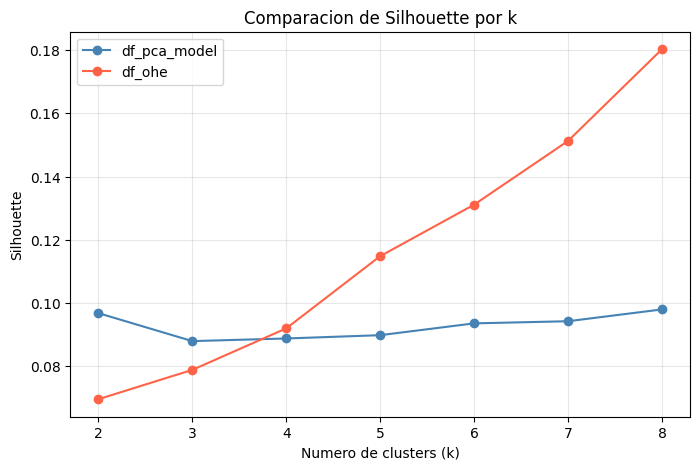

In [33]:
# Comparacion K-Means entre base PCA y base con one-hot de variables tramificadas

if 'df_pca_model' not in globals():
    raise ValueError('Primero ejecuta la celda de PCA para crear df_pca_model.')
if 'df_ohe' not in globals():
    raise ValueError('Primero ejecuta la celda de one-hot encoding para tener df_ohe.')

def evaluar_kmeans(base, nombre_base, ks=range(2, 9)):
    X_base = base.drop(columns=['Outcome'], errors='ignore').copy()

    # Aseguramos formato numerico para K-Means
    X_base = X_base.apply(lambda s: s.astype(int) if s.dtype == bool else s)

    X_sc = StandardScaler().fit_transform(X_base)
    resultados = []

    for k in ks:
        km = KMeans(n_clusters=k, n_init=20, random_state=42)
        labels = km.fit_predict(X_sc)

        resultados.append({
            'Base': nombre_base,
            'k': k,
            'Silhouette': silhouette_score(X_sc, labels),
            'Calinski-Harabasz': calinski_harabasz_score(X_sc, labels),
            'Davies-Bouldin': davies_bouldin_score(X_sc, labels)
        })

    df_res = pd.DataFrame(resultados)
    mejor = df_res.sort_values('Silhouette', ascending=False).iloc[0]
    return df_res, mejor

res_pca, mejor_pca = evaluar_kmeans(df_pca_model, 'df_pca_model')
res_ohe, mejor_ohe = evaluar_kmeans(df_ohe, 'df_ohe')

resumen_completo = pd.concat([res_pca, res_ohe], ignore_index=True)
resumen_mejores = pd.DataFrame([mejor_pca, mejor_ohe]).reset_index(drop=True)

print('Desempeno por k y por base:')
display(resumen_completo.round(4))

print('Mejor configuracion por base (ordenado por Silhouette):')
display(resumen_mejores[['Base', 'k', 'Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']].round(4))

# Visualizacion comparativa de Silhouette por k
fig, ax = plt.subplots(figsize=(8, 5))
for base_name, color in [('df_pca_model', 'steelblue'), ('df_ohe', 'tomato')]:
    d = resumen_completo[resumen_completo['Base'] == base_name]
    ax.plot(d['k'], d['Silhouette'], marker='o', label=base_name, color=color)

ax.set_title('Comparacion de Silhouette por k')
ax.set_xlabel('Numero de clusters (k)')
ax.set_ylabel('Silhouette')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

#### 9) Grafico del indice Silhouette para $k=4$

Este grafico muestra el valor silhouette de cada observacion segun su cluster cuando $k=4$.
Ayuda a validar si los grupos obtenidos estan bien separados y son internamente coherentes.

Como leer el grafico:

- Cada banda horizontal corresponde a un cluster.
- El ancho hacia la derecha representa mejor asignacion al cluster.
- Valores cercanos a 0 indican fronteras difusas entre clusters.
- Valores negativos sugieren posible mala asignacion.
- La linea punteada roja marca el silhouette promedio global.

Si la mayoria de los puntos queda con valores positivos y alejados de 0, la particion suele ser mas confiable.

Base usada: df_pca_model
Silhouette promedio (k=4): 0.0888


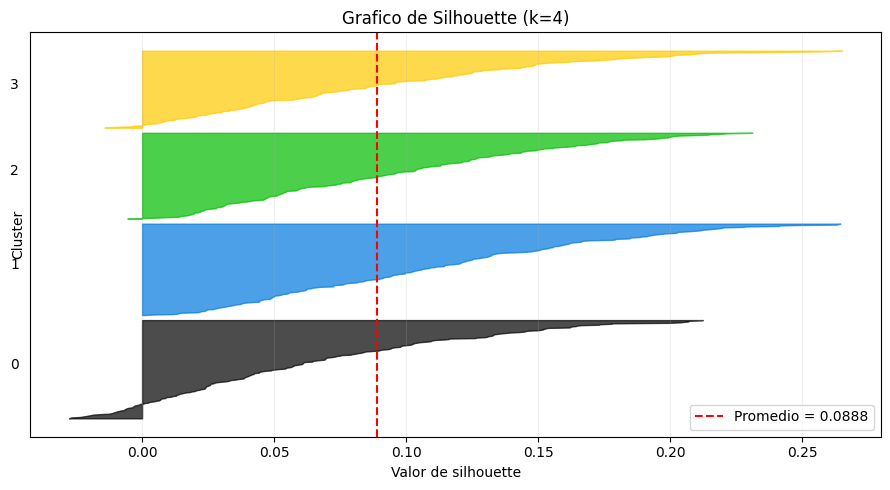

In [34]:
# Grafico del indice de Silhouette para k = 4

# Seleccion automatica de base (prioridad: PCA -> OHE -> depurada)
if 'df_pca_model' in globals():
    base_name = 'df_pca_model'
    base = df_pca_model.copy()
elif 'df_ohe' in globals():
    base_name = 'df_ohe'
    base = df_ohe.copy()
else:
    base_name = 'df_model'
    base = df_model.copy()

X_sil = base.drop(columns=['Outcome'], errors='ignore').copy()
X_sil = X_sil.apply(lambda s: s.astype(int) if s.dtype == bool else s)
X_sil_sc = StandardScaler().fit_transform(X_sil)

k = 4
kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
labels = kmeans.fit_predict(X_sil_sc)

sil_avg = silhouette_score(X_sil_sc, labels)
sil_values = silhouette_samples(X_sil_sc, labels)

print(f"Base usada: {base_name}")
print(f"Silhouette promedio (k=4): {sil_avg:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10

for i in range(k):
    ith = sil_values[labels == i]
    ith.sort()
    size_i = ith.shape[0]
    y_upper = y_lower + size_i

    color = plt.cm.nipy_spectral(float(i) / k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith, facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=1.5, label=f'Promedio = {sil_avg:.4f}')
ax.set_title('Grafico de Silhouette (k=4)')
ax.set_xlabel('Valor de silhouette')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#### 10) Relación entre cluster y variable Outcome

En esta sección cruzamos los clusters obtenidos con la etiqueta clínica `Outcome` para interpretar cada grupo y observar si existe concentración diferenciada de casos con y sin diabetes.

Base usada para clustering: df_pca_model

Conteos Cluster x Outcome:


Outcome,0,1
Cluster,,
0,155,59
1,125,74
2,137,50
3,83,85


Porcentaje por cluster (%):


Outcome,0,1
Cluster,,
0,72.43,27.57
1,62.81,37.19
2,73.26,26.74
3,49.40,50.60


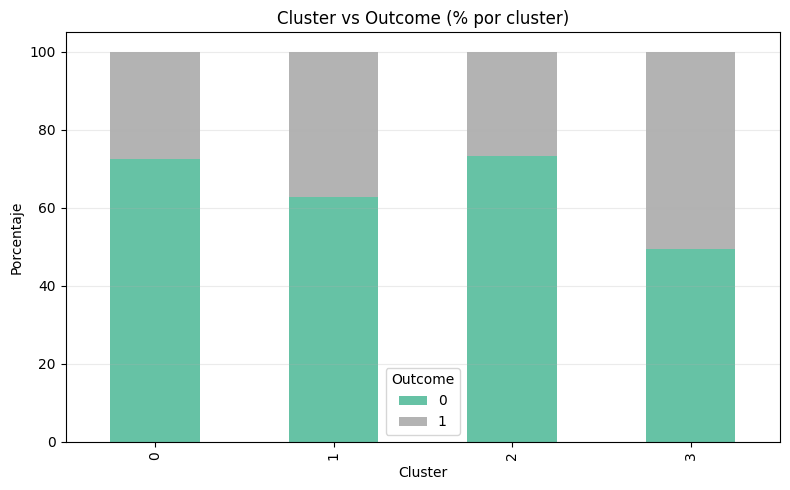

In [15]:
# Cruce Cluster vs Outcome (k=4)
# Usamos la misma lógica de base: PCA -> OHE -> df_model
if 'df_pca_model' in globals():
    base_name = 'df_pca_model'
    base = df_pca_model.copy()
elif 'df_ohe' in globals():
    base_name = 'df_ohe'
    base = df_ohe.copy()
else:
    base_name = 'df_model'
    base = df_model.copy()

if 'Outcome' not in df_model.columns:
    raise ValueError('No se encontró la variable Outcome en df_model.')

X_cross = base.drop(columns=['Outcome'], errors='ignore').copy()
X_cross = X_cross.apply(lambda s: s.astype(int) if s.dtype == bool else s)
X_cross_sc = StandardScaler().fit_transform(X_cross)

k = 4
kmeans_cross = KMeans(n_clusters=k, n_init=20, random_state=42)
cluster_labels = kmeans_cross.fit_predict(X_cross_sc)

df_cross = pd.DataFrame({
    'Cluster': cluster_labels,
    'Outcome': df_model['Outcome'].values
})

tabla_conteos = pd.crosstab(df_cross['Cluster'], df_cross['Outcome'])
tabla_pct = pd.crosstab(df_cross['Cluster'], df_cross['Outcome'], normalize='index') * 100

print(f"Base usada para clustering: {base_name}")
print('\nConteos Cluster x Outcome:')
display(tabla_conteos)

print('Porcentaje por cluster (%):')
display(tabla_pct.round(2))

# Gráfico apilado de proporciones
tabla_pct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')
plt.title('Cluster vs Outcome (% por cluster)')
plt.xlabel('Cluster')
plt.ylabel('Porcentaje')
plt.legend(title='Outcome')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

#### Diferencias entre clusters - Visualizacion 3D interactiva

En esta seccion proyectamos los datos en los tres primeros componentes principales y comparamos la estructura de los clusters en un panel 2x2. Puedes rotar, hacer zoom y revisar valores clinicos relevantes al pasar el cursor sobre cada punto.

In [36]:
# Proyeccion 3D comun
pca_3d = PCA(n_components=3, random_state=42)
X_3d = pca_3d.fit_transform(StandardScaler().fit_transform(X))

df_3d = pd.DataFrame(X_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d['Cluster'] = cluster_labels.astype(str)

for v in ['Glucose', 'BMI', 'Age']:
    if v in df_model.columns:
        df_3d[v] = df_model[v].values

hover_cols = [v for v in ['Glucose', 'BMI', 'Age'] if v in df_3d.columns]
clusters_ordenados = sorted(df_3d['Cluster'].unique())
paleta = px.colors.qualitative.Set2
color_map = {c: paleta[i % len(paleta)] for i, c in enumerate(clusters_ordenados)}

configs = [
    ('Solo cluster 0', ['0']),
    ('Clusters 0 y 1', ['0', '1']),
    ('Clusters 0, 1 y 2', ['0', '1', '2']),
    ('Todos los clusters', clusters_ordenados),
]

# Figura 2x2 (2 columnas)
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}],
           [{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=[cfg[0] for cfg in configs],
    horizontal_spacing=0.04,
    vertical_spacing=0.08
)

for idx, (titulo, clusters_visibles) in enumerate(configs, start=1):
    row = 1 if idx <= 2 else 2
    col = 1 if idx in [1, 3] else 2

    subset = df_3d[df_3d['Cluster'].isin(clusters_visibles)]
    if subset.empty:
        continue

    for c in clusters_visibles:
        d = subset[subset['Cluster'] == c]
        if d.empty:
            continue

        custom_data = d[hover_cols].values if hover_cols else None
        hover_tmpl = 'Cluster=' + str(c) + '<br>Componente 1=%{x:.2f}<br>Componente 2=%{y:.2f}<br>Componente 3=%{z:.2f}'
        if 'Glucose' in hover_cols:
            hover_tmpl += '<br>Glucosa=%{customdata[' + str(hover_cols.index('Glucose')) + ']}'
        if 'BMI' in hover_cols:
            hover_tmpl += '<br>IMC=%{customdata[' + str(hover_cols.index('BMI')) + ']}'
        if 'Age' in hover_cols:
            hover_tmpl += '<br>Edad=%{customdata[' + str(hover_cols.index('Age')) + ']}'
        hover_tmpl += '<extra></extra>'

        fig.add_trace(
            go.Scatter3d(
                x=d['PC1'],
                y=d['PC2'],
                z=d['PC3'],
                mode='markers',
                name=f'Cluster {c}',
                legendgroup=f'cluster_{c}',
                showlegend=(idx == 4),
                marker=dict(size=4, opacity=0.75, color=color_map.get(c, '#1f77b4')),
                customdata=custom_data,
                hovertemplate=hover_tmpl
            ),
            row=row, col=col
        )

# Titulos de ejes para cada escena
fig.update_layout(
    title='Panel 3D de clusters (2x2)',
    width=1200,
    height=900,
    legend_title_text='Grupos (cluster)',
    margin=dict(l=0, r=0, t=60, b=0),
    scene=dict(xaxis_title='Componente principal 1', yaxis_title='Componente principal 2', zaxis_title='Componente principal 3'),
    scene2=dict(xaxis_title='Componente principal 1', yaxis_title='Componente principal 2', zaxis_title='Componente principal 3'),
    scene3=dict(xaxis_title='Componente principal 1', yaxis_title='Componente principal 2', zaxis_title='Componente principal 3'),
    scene4=dict(xaxis_title='Componente principal 1', yaxis_title='Componente principal 2', zaxis_title='Componente principal 3')
)

fig.show()